# Model Quality Estimation — Validation, Feature Selection & Hyperparameter Optimization

**School 21 — ML project.**  We study how to split a dataset correctly to
measure model quality without leakage, then optimize hyperparameters and select
features.

Dataset: a stand-in for Kaggle's *Two Sigma Connect: Rental Listing Inquiries*
(`datasets/train.json`).  It has the same schema (`created`, `features`,
`manager_id`, `price`, `interest_level`, ...) and is generated by
`src/generate_dataset.py` so the whole notebook is reproducible.  The regression
**target is `price`**; `manager_id` is the natural **group**; `interest_level`
is the natural **stratification** label; `created` carries the **time** signal.

## Chapter V.1 — Theory answers

### 1.1  Leave-One-Out (LOO) cross-validation

LOO is K-Fold cross-validation taken to the extreme **K = N** (N = number of
samples).  Each fold uses exactly **one** observation as the test set and the
remaining **N − 1** observations for training; the model is therefore trained
N times and the score is the average over the N single-point test errors.

**Strengths**
- *Almost unbiased* estimate of generalization error: each model trains on
  N − 1 points, i.e. virtually the whole dataset, so the estimate is very close
  to the performance of the final model trained on all N points.
- *Deterministic*: there is no randomness in the fold assignment — every point
  is the test set exactly once, so the estimate is fully reproducible.
- Uses the data maximally — valuable when N is tiny (e.g. expensive medical data).

**Limitations**
- *Computationally expensive*: trains N models. For N = 10 000 that is 10 000
  fits — infeasible for anything but small data or cheap models.
- *High variance* of the estimate: the N training sets are almost identical
  (they differ by one point), so the N error terms are highly correlated and
  averaging them reduces variance poorly. The LOO estimate can vary a lot from
  dataset to dataset.
- Can be *pathological for unstable metrics* (e.g. a single test point gives a
  0/1 classification error, so per-fold scores are extreme).

### 1.2  Grid Search, Randomized Grid Search, Bayesian optimization

**Grid Search** — define a discrete grid of candidate values for each
hyperparameter and evaluate **every** combination (the Cartesian product) with
cross-validation, keeping the best. Pros: exhaustive, trivially parallel,
reproducible. Cons: cost grows **exponentially** with the number of
hyperparameters (curse of dimensionality); wastes budget on unpromising regions;
resolution limited by the chosen grid.

**Randomized Grid Search** — instead of all combinations, sample a fixed number
`n_iter` of combinations at random from (possibly continuous) distributions.
Bergstra & Bengio (2012) showed random search finds good configurations faster
than grid search when only a few hyperparameters actually matter, because it
explores **more distinct values** of the important parameter for the same
budget. Pros: budget is decoupled from dimensionality; better coverage of
continuous ranges. Cons: still **uninformed** — it ignores results already seen.

**Bayesian optimization** — treats validation-score = f(hyperparameters) as an
unknown, expensive black-box function and builds a cheap *probabilistic
surrogate* of it (a Gaussian Process, or a Tree-structured Parzen Estimator /
TPE as in Optuna/Hyperopt). At each step it uses an **acquisition function**
(e.g. Expected Improvement) that balances *exploitation* (sample where the
surrogate predicts high score) against *exploration* (sample where the surrogate
is uncertain) to choose the next configuration, evaluates it, and updates the
surrogate. This way it **uses past evaluations** to focus the search and usually
reaches a good optimum in far fewer trials than grid/random search.
TPE specifically models `p(x | y)` by splitting trials into "good" (`l(x)`) and
"bad" (`g(x)`) groups and proposes points that maximize `l(x)/g(x)`.

### 1.3  Feature-selection methods

Feature-selection methods are usually grouped as:

- **Unsupervised** — ignore the target. E.g. drop features with too many NaNs,
  near-zero variance, or one of each pair of highly correlated features (keep
  one, remove the redundant). Cheap, but can drop predictive columns.
- **Supervised**, which split into three families:
  - **Filters** — rank each feature by a statistical association with the
    target, independently of any model, then keep the top-k. Fast and model-
    agnostic but ignore feature interactions.
  - **Wrappers** — search over feature subsets, training the actual model on
    each subset and scoring it (forward selection, backward elimination, RFE,
    exhaustive search). Account for interactions and tailor to the model, but
    are expensive (many model fits) and can overfit the validation set.
  - **Embedded** — selection happens *inside* model training, e.g. L1
    (Lasso) shrinks irrelevant weights to exactly 0, or tree importances.
    A good cost/quality trade-off.

**Pearson correlation (filter)** — measures the *linear* association between a
numeric feature x and numeric target y:
`r = cov(x, y) / (σ_x · σ_y)`, `r ∈ [−1, 1]`. We rank features by `|r|`. Only
captures linear, monotone relationships; blind to non-linear signal.

**Chi-squared, χ² (filter)** — for a *categorical* (non-negative) feature vs a
*categorical* target. It compares the observed co-occurrence counts in the
contingency table with the counts *expected under independence*:
`χ² = Σ (O − E)² / E`. A large χ² ⇒ feature and target are dependent ⇒ the
feature is informative. Requires non-negative features (counts / one-hot).

**Lasso (embedded)** — linear regression with an L1 penalty:
`min ‖y − Xw‖² + α·‖w‖₁`. The L1 ball has corners on the axes, so the optimum
tends to land where several `w_j = 0` exactly — the model performs selection
while fitting. Larger `α` ⇒ sparser model. (Ridge uses L2 `‖w‖²`, which shrinks
weights smoothly toward 0 but never exactly to 0, so Ridge regularizes but does
**not** select.)

**Permutation importance** — model-agnostic, measured *after* training: take a
fitted model and a validation set, record the baseline score, then for one
feature **randomly shuffle its column** (breaking its link to the target) and
re-score. The drop in score = that feature's importance. Repeat per feature
(and several times to average noise). Captures the feature's real contribution
*to this model*, including interactions; cost = a few extra scorings, no refit.

**SHAP (SHapley Additive exPlanations)** — assigns each feature, *for each
prediction*, a contribution value grounded in cooperative-game theory (Shapley
values): the feature's average marginal contribution over all orderings of the
features. SHAP values are *additive* (they sum to the prediction minus the base
value) and consistent. Averaging `|SHAP|` over the dataset gives a global
importance ranking; unlike a single global number it also explains *individual*
predictions. We use the `shap` library.

## Chapter V.2 — Setup, data loading & feature engineering

In [1]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = os.path.join("datasets", "train.json")
# Generate the dataset on first run if it is missing.
if not os.path.exists(DATA_PATH):
    import subprocess, sys
    subprocess.run([sys.executable, os.path.join("src", "generate_dataset.py")], check=True)

df = pd.read_json(DATA_PATH)
df["created"] = pd.to_datetime(df["created"])
print("shape:", df.shape)
df.head(3)

shape: (10000, 15)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
0,1.0,2,b00871,2016-04-01 21:34:00,,151 Main St,"[Laundry in Unit, Furnished, Dishwasher, Duple...",40.728782,7000000,-73.940930,m0354,[],4374,140 Main St,medium
1,1.0,0,b01321,2016-04-01 22:35:00,,144 Main St,"[Hardwood Floors, Laundry in Building, Laundry...",40.729195,7000001,-73.945069,m0066,[],1806,157 Main St,high
2,1.5,0,b00166,2016-04-01 11:53:00,,91 Main St,[Elevator],40.749630,7000002,-73.976629,m0287,[],2533,263 Main St,low


In [2]:
# ----- Feature engineering: one-hot the 20 amenities from the `features` list ---
TARGET_FEATURES = [
    'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
    'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
    'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom',
    'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding',
    'NewConstruction', 'Terrace',
]

def normalize(token: str) -> str:
    "Collapse casing/spacing/punctuation so 'Hardwood Floors' -> 'hardwoodfloors'."
    return "".join(ch for ch in token.lower() if ch.isalnum())

NORM_TO_FEATURE = {normalize(f): f for f in TARGET_FEATURES}

def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    # start every amenity column at 0
    for f in TARGET_FEATURES:
        frame[f] = 0
    for idx, feats in frame["features"].items():
        for token in (feats or []):
            col = NORM_TO_FEATURE.get(normalize(token))
            if col is not None:
                frame.at[idx, col] = 1
    return frame

df = engineer_features(df)
print("Engineered amenity columns; e.g. Doorman positives:", int(df["Doorman"].sum()))
df[TARGET_FEATURES].head(3)

Engineered amenity columns; e.g. Doorman positives: 1697


,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# Build the modeling table: numeric base features + engineered amenities.
BASE_NUMERIC = ["bedrooms", "bathrooms", "latitude", "longitude"]
FEATURE_COLS = BASE_NUMERIC + TARGET_FEATURES
TARGET = "price"

model_df = df[FEATURE_COLS + [TARGET, "created", "manager_id", "interest_level"]].copy()
print("Feature matrix columns:", len(FEATURE_COLS))
model_df.describe().T[["mean", "min", "max"]].head()

Feature matrix columns: 24


,mean,min,max
bedrooms,1.9939,0.0,4.0
bathrooms,1.7533,1.0,3.0
latitude,40.749582,40.635621,40.872638
longitude,-73.96952,-74.075177,-73.834798
Elevator,0.1705,0.0,1.0


## Chapter V.3 — Hold-out splitting methods

We implement, from scratch:
1. random 2-way split (`test_size`),
2. random 3-way split (`validation_size`, `test_size`),
3. date 2-way split (`date_split`),
4. date 3-way split (`validation_date`, `test_date`),
5. **determinism** via `random_state`.

> **What does "deterministic split" mean?** Given the same data and the same
> parameters, the split must return the **exact same** rows every time it is
> run. We achieve this by seeding the random permutation with a fixed
> `random_state` — without it, each run would shuffle differently and results
> (and any leakage checks) would be irreproducible. Time-based splits are
> deterministic by construction (they depend only on the date threshold).

In [4]:
def random_split_2(data, test_size=0.2, random_state=RANDOM_STATE):
    "Random 2-way split. Returns (train, test)."
    assert 0.0 < test_size < 1.0
    rng = np.random.default_rng(random_state)        # seeded -> deterministic
    idx = rng.permutation(len(data))
    n_test = int(round(len(data) * test_size))
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return data.iloc[train_idx], data.iloc[test_idx]


def random_split_3(data, validation_size=0.2, test_size=0.2, random_state=RANDOM_STATE):
    "Random 3-way split. Returns (train, valid, test)."
    assert 0.0 < validation_size + test_size < 1.0
    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(data))
    n = len(data)
    n_test = int(round(n * test_size))
    n_valid = int(round(n * validation_size))
    test_idx = idx[:n_test]
    valid_idx = idx[n_test:n_test + n_valid]
    train_idx = idx[n_test + n_valid:]
    return data.iloc[train_idx], data.iloc[valid_idx], data.iloc[test_idx]


tr, te = random_split_2(model_df, test_size=0.2)
trn, val, tst = random_split_3(model_df, 0.2, 0.2)
print(f"2-way : train={len(tr)}  test={len(te)}")
print(f"3-way : train={len(trn)}  valid={len(val)}  test={len(tst)}")

2-way : train=8000  test=2000
3-way : train=6000  valid=2000  test=2000


In [5]:
def date_split_2(data, date_split, date_field="created"):
    "Out-of-time 2-way split: rows before `date_split` -> train, else test."
    ts = pd.to_datetime(date_split)
    mask = data[date_field] < ts
    return data[mask], data[~mask]


def date_split_3(data, validation_date, test_date, date_field="created"):
    "Out-of-time 3-way split by two thresholds (validation_date < test_date)."
    v, t = pd.to_datetime(validation_date), pd.to_datetime(test_date)
    assert v < t
    train = data[data[date_field] < v]
    valid = data[(data[date_field] >= v) & (data[date_field] < t)]
    test = data[data[date_field] >= t]
    return train, valid, test


print("created range:", model_df["created"].min(), "->", model_df["created"].max())
tr, te = date_split_2(model_df, "2016-07-01")
trn, val, tst = date_split_3(model_df, "2016-06-15", "2016-07-15")
print(f"OOT 2-way : train={len(tr)}  test={len(te)}")
print(f"OOT 3-way : train={len(trn)}  valid={len(val)}  test={len(tst)}")

# Determinism check: same params -> identical rows.
a, _ = random_split_2(model_df, 0.2, random_state=7)
b, _ = random_split_2(model_df, 0.2, random_state=7)
print("deterministic (same seed identical):", a.index.equals(b.index))
c, _ = random_split_2(model_df, 0.2, random_state=8)
print("different seed -> different split   :", not a.index.equals(c.index))

created range: 2016-04-01 00:15:00 -> 2016-09-28 22:34:00
OOT 2-way : train=5026  test=4974
OOT 3-way : train=4234  valid=1658  test=4108
deterministic (same seed identical): True
different seed -> different split   : True


## Chapter V.4 — Cross-validation methods (from scratch)

Each function returns a **list of `(train_idx, test_idx)`** positional-index
pairs, the same contract sklearn's `split()` uses.

In [6]:
def kfold_split(data, k=5, random_state=RANDOM_STATE, shuffle=True):
    "Plain K-Fold. Returns list of (train_idx, test_idx)."
    n = len(data)
    idx = np.arange(n)
    if shuffle:
        np.random.default_rng(random_state).shuffle(idx)
    folds = np.array_split(idx, k)
    out = []
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        out.append((np.sort(train_idx), np.sort(test_idx)))
    return out


def group_kfold_split(data, k=5, group_field="manager_id"):
    "Group K-Fold: a whole group lands entirely in train OR in test (no leak)."
    groups = data[group_field].values
    unique = pd.unique(groups)
    # greedy: assign each group (largest first) to the currently smallest fold
    counts = pd.Series(groups).value_counts()
    fold_sizes = np.zeros(k, dtype=int)
    group_to_fold = {}
    for g in counts.index:                      # large groups first -> balance
        f = int(np.argmin(fold_sizes))
        group_to_fold[g] = f
        fold_sizes[f] += counts[g]
    fold_of_row = np.array([group_to_fold[g] for g in groups])
    out = []
    for i in range(k):
        test_idx = np.where(fold_of_row == i)[0]
        train_idx = np.where(fold_of_row != i)[0]
        out.append((train_idx, test_idx))
    return out


def stratified_kfold_split(data, k=5, stratify_field="interest_level",
                           random_state=RANDOM_STATE):
    "Stratified K-Fold: each fold keeps the class proportions of `stratify_field`."
    y = data[stratify_field].values
    rng = np.random.default_rng(random_state)
    fold_of_row = np.empty(len(data), dtype=int)
    for cls in pd.unique(y):                    # distribute each class round-robin
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        fold_of_row[cls_idx] = np.arange(len(cls_idx)) % k
    out = []
    for i in range(k):
        test_idx = np.where(fold_of_row == i)[0]
        train_idx = np.where(fold_of_row != i)[0]
        out.append((train_idx, test_idx))
    return out


def timeseries_split(data, k=5, date_field="created"):
    "Expanding-window time-series split -> k-1 (train, test) pairs."
    order = np.argsort(data[date_field].values, kind="mergesort")  # stable, by time
    folds = np.array_split(order, k)
    out = []
    for i in range(1, k):
        train_idx = np.concatenate(folds[:i])   # everything before window i
        test_idx = folds[i]
        out.append((train_idx, test_idx))
    return out


for name, splits in [
    ("K-Fold", kfold_split(model_df, 5)),
    ("Group K-Fold", group_kfold_split(model_df, 5)),
    ("Stratified K-Fold", stratified_kfold_split(model_df, 5)),
    ("TimeSeriesSplit", timeseries_split(model_df, 5)),
]:
    sizes = [(len(tr), len(te)) for tr, te in splits]
    print(f"{name:20s}: {len(splits)} folds, (train,test) sizes -> {sizes}")

K-Fold              : 5 folds, (train,test) sizes -> [(8000, 2000), (8000, 2000), (8000, 2000), (8000, 2000), (8000, 2000)]
Group K-Fold        : 5 folds, (train,test) sizes -> [(8000, 2000), (8000, 2000), (8000, 2000), (8000, 2000), (8000, 2000)]
Stratified K-Fold   : 5 folds, (train,test) sizes -> [(7999, 2001), (7999, 2001), (7999, 2001), (8001, 1999), (8002, 1998)]
TimeSeriesSplit     : 4 folds, (train,test) sizes -> [(2000, 2000), (4000, 2000), (6000, 2000), (8000, 2000)]


## Chapter V.5 — Cross-validation comparison vs sklearn

We (1) apply every scheme, (2) reproduce each with the sklearn equivalent,
(3) compare the resulting **training feature distributions**, and
(4) compare schemes to pick the best one for this dataset.

In [7]:
from sklearn.model_selection import (KFold, GroupKFold, StratifiedKFold,
                                      TimeSeriesSplit)

# (5.1) Preprocess the target for the Stratified scheme: it needs a categorical
# label. We use `interest_level` directly (already categorical).
y_strat = model_df["interest_level"].values

# ---- verify Group K-Fold really has NO group leakage between train & test ----
def group_leak(splits, groups):
    leaks = 0
    for tr, te in splits:
        if set(groups[tr]) & set(groups[te]):
            leaks += 1
    return leaks

groups = model_df["manager_id"].values
print("Our GroupKFold leaking folds:", group_leak(group_kfold_split(model_df, 5), groups))

# ---- verify Stratified keeps class ratios ----
overall = pd.Series(y_strat).value_counts(normalize=True).sort_index()
print("\nOverall interest_level ratios:\n", overall.round(3).to_dict())
for i, (tr, te) in enumerate(stratified_kfold_split(model_df, 5)):
    ratios = pd.Series(y_strat[te]).value_counts(normalize=True).sort_index()
    print(f"  fold {i} test ratios:", {k: round(v, 3) for k, v in ratios.items()})

Our GroupKFold leaking folds: 0

Overall interest_level ratios:
 {'high': 0.143, 'low': 0.5, 'medium': 0.357}
  fold 0 test ratios: {'high': 0.143, 'low': 0.5, 'medium': 0.357}
  fold 1 test ratios: {'high': 0.143, 'low': 0.5, 'medium': 0.357}
  fold 2 test ratios: {'high': 0.143, 'low': 0.5, 'medium': 0.357}
  fold 3 test ratios: {'high': 0.143, 'low': 0.5, 'medium': 0.357}
  fold 4 test ratios: {'high': 0.143, 'low': 0.501, 'medium': 0.357}


In [8]:
# (5.2 / 5.3) Compare the TRAIN feature distribution of OUR implementation vs
# sklearn's, fold 0, for a few features. They should be statistically identical.
sk_kfold = list(KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(model_df))
my_kfold = kfold_split(model_df, 5)

def train_means(splits):
    tr_idx = splits[0][0]
    return model_df.iloc[tr_idx][["price", "bedrooms"] + TARGET_FEATURES[:4]].mean()

cmp = pd.DataFrame({"ours": train_means(my_kfold), "sklearn": train_means(sk_kfold)})
cmp["abs_diff"] = (cmp["ours"] - cmp["sklearn"]).abs()
print(cmp.round(3))

# KS test: are the train price distributions the same shape? (p>0.05 => yes)
ks = stats.ks_2samp(model_df.iloc[my_kfold[0][0]]["price"],
                    model_df.iloc[sk_kfold[0][0]]["price"])
print(f"\nKS test (ours vs sklearn train price): stat={ks.statistic:.3f}, p={ks.pvalue:.3f}")

                    ours   sklearn  abs_diff
price           4571.378  4569.665     1.713
bedrooms           1.989     1.991     0.002
Elevator           0.171     0.168     0.003
HardwoodFloors     0.171     0.169     0.002
CatsAllowed        0.176     0.174     0.003
DogsAllowed        0.171     0.170     0.001

KS test (ours vs sklearn train price): stat=0.004, p=1.000


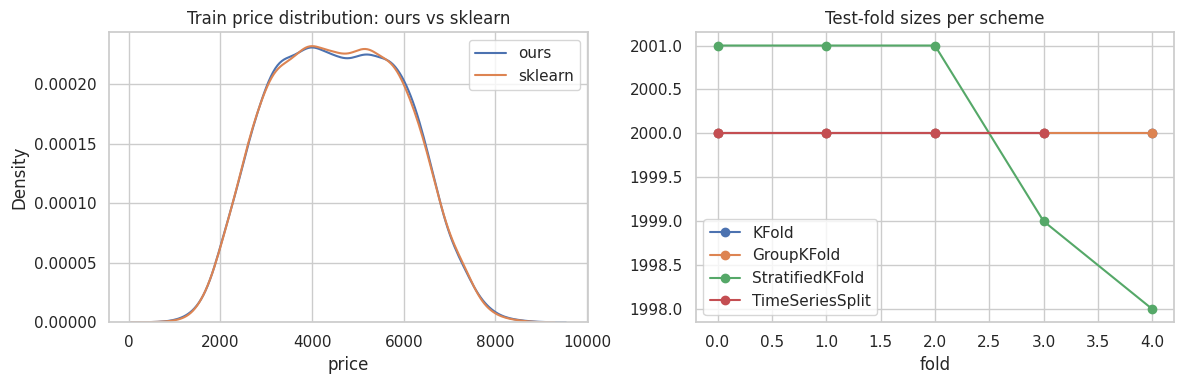

In [9]:
# Visual check: train `price` distribution overlaps between our split & sklearn.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(model_df.iloc[my_kfold[0][0]]["price"], label="ours", ax=ax[0])
sns.kdeplot(model_df.iloc[sk_kfold[0][0]]["price"], label="sklearn", ax=ax[0])
ax[0].set_title("Train price distribution: ours vs sklearn"); ax[0].legend()

# fold-size comparison across schemes
schemes = {
    "KFold": my_kfold,
    "GroupKFold": group_kfold_split(model_df, 5),
    "StratifiedKFold": stratified_kfold_split(model_df, 5),
    "TimeSeriesSplit": timeseries_split(model_df, 5),
}
for name, sp in schemes.items():
    ax[1].plot([len(te) for _, te in sp], marker="o", label=name)
ax[1].set_title("Test-fold sizes per scheme"); ax[1].set_xlabel("fold"); ax[1].legend()
plt.tight_layout(); plt.show()

In [10]:
# (5.4) Compare schemes by running the SAME model through each and looking at
# the mean & spread of the validation metric. Lower RMSE std => more stable.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X_all = model_df[FEATURE_COLS].values
y_all = model_df[TARGET].values

def cv_score(splits):
    rmses, r2s = [], []
    for tr, te in splits:
        sc = StandardScaler().fit(X_all[tr])
        m = LinearRegression().fit(sc.transform(X_all[tr]), y_all[tr])
        pred = m.predict(sc.transform(X_all[te]))
        rmses.append(mean_squared_error(y_all[te], pred) ** 0.5)
        r2s.append(r2_score(y_all[te], pred))
    return np.mean(rmses), np.std(rmses), np.mean(r2s)

rows = []
for name, sp in schemes.items():
    m_rmse, s_rmse, m_r2 = cv_score(sp)
    rows.append({"scheme": name, "mean_RMSE": m_rmse, "std_RMSE": s_rmse, "mean_R2": m_r2})
summary = pd.DataFrame(rows).set_index("scheme").round(3)
print(summary)

                 mean_RMSE  std_RMSE  mean_R2
scheme                                       
KFold              362.555     3.390    0.933
GroupKFold         362.659     2.800    0.933
StratifiedKFold    362.602     5.416    0.933
TimeSeriesSplit    362.602     4.337    0.932


**Choosing the best scheme.** For *this* dataset the listings are
quasi-independent and we predict `price` (no strong forecasting requirement),
so a plain **K-Fold** gives the lowest-variance, least-biased estimate and uses
all data. However:

- If we cared about **deploying forward in time**, `TimeSeriesSplit` is the
  honest choice — it never trains on the future, matching production.
- Because one **manager** lists many flats and sets prices similarly,
  `GroupKFold` (group = `manager_id`) is the **safest against leakage**: it
  guarantees the model is evaluated on *unseen managers*, which is the realistic
  generalization question. We therefore recommend **GroupKFold** as the default
  for honest model selection here, and report plain K-Fold only as an optimistic
  upper bound.

## Chapter V.6 — Feature selection

We split the samples **by the `created` field** into a 3-way **60/20/20**
train/validation/test split (out-of-time, using our own `date_split_3`),
normalize the features, take a **Lasso** baseline, then compare four selection
strategies on **speed, metric and stability**.

In [11]:
from sklearn.linear_model import Lasso

# (6.1) 60/20/20 split BY DATE (`created`): the 0.6 / 0.8 quantiles of the
# timestamp become the validation / test thresholds for our own date_split_3.
validation_date = model_df["created"].quantile(0.6)
test_date = model_df["created"].quantile(0.8)
print(f"validation_date={validation_date}  test_date={test_date}")

train_df, valid_df, test_df = date_split_3(model_df, validation_date, test_date)
print(f"train={len(train_df)} ({len(train_df)/len(model_df):.0%})  "
      f"valid={len(valid_df)} ({len(valid_df)/len(model_df):.0%})  "
      f"test={len(test_df)} ({len(test_df)/len(model_df):.0%})")
scaler = StandardScaler().fit(train_df[FEATURE_COLS].values)
Xtr = scaler.transform(train_df[FEATURE_COLS].values); ytr = train_df[TARGET].values
Xva = scaler.transform(valid_df[FEATURE_COLS].values); yva = valid_df[TARGET].values
Xte = scaler.transform(test_df[FEATURE_COLS].values);  yte = test_df[TARGET].values

def evaluate(cols, label, model=None):
    "Fit on selected columns, report valid+test RMSE/R2."
    j = [FEATURE_COLS.index(c) for c in cols]
    mdl = model or Lasso(alpha=1.0, random_state=RANDOM_STATE)
    mdl.fit(Xtr[:, j], ytr)
    pv = mdl.predict(Xva[:, j]); pt = mdl.predict(Xte[:, j])
    return {
        "method": label, "n_features": len(cols),
        "valid_RMSE": mean_squared_error(yva, pv) ** 0.5,
        "test_RMSE": mean_squared_error(yte, pt) ** 0.5,
        "test_R2": r2_score(yte, pt),
    }

# (6.1) Lasso on ALL features = baseline.
base_lasso = Lasso(alpha=1.0, random_state=RANDOM_STATE).fit(Xtr, ytr)
results = [evaluate(FEATURE_COLS, "Lasso (all features)")]
print(results[-1])

validation_date=2016-07-16 22:57:48  test_date=2016-08-22 21:40:24
train=6000 (60%)  valid=2000 (20%)  test=2000 (20%)
{'method': 'Lasso (all features)', 'n_features': 24, 'valid_RMSE': 355.43563966696536, 'test_RMSE': 362.96542299212985, 'test_R2': 0.9312050963791797}


In [12]:
# (6.2) Sort features by |Lasso weight|, keep top 10, refit, compare.
coef = pd.Series(np.abs(base_lasso.coef_), index=FEATURE_COLS).sort_values(ascending=False)
top10_lasso = coef.head(10).index.tolist()
print("Top-10 by Lasso weight:", top10_lasso)
t0 = time.time(); r = evaluate(top10_lasso, "Lasso top-10 (by weight)"); r["sec"] = time.time() - t0
results.append(r); print(r)

Top-10 by Lasso weight: ['bedrooms', 'bathrooms', 'Doorman', 'SwimmingPool', 'FitnessCenter', 'Terrace', 'RoofDeck', 'NewConstruction', 'Balcony', 'LaundryinUnit']
{'method': 'Lasso top-10 (by weight)', 'n_features': 10, 'valid_RMSE': 375.83515140185943, 'test_RMSE': 392.63432641590776, 'test_R2': 0.9194988123643847, 'sec': 0.0034685134887695312}


In [13]:
# (6.3) Simple UNSUPERVISED selection: drop high-NaN columns and one of every
# highly-correlated pair, then keep the 10 highest-variance survivors.
def nan_corr_select(frame, cols, nan_thresh=0.3, corr_thresh=0.9, top=10):
    sub = frame[cols]
    keep = [c for c in cols if sub[c].isna().mean() <= nan_thresh]   # nan filter
    corr = sub[keep].corr().abs()
    drop = set()
    for i, a in enumerate(keep):
        for b in keep[i + 1:]:
            if corr.loc[a, b] > corr_thresh:
                drop.add(b)                                          # redundant
    keep = [c for c in keep if c not in drop]
    variances = frame[keep].var().sort_values(ascending=False)      # rank by var
    return variances.head(top).index.tolist()

t0 = time.time()
sel_nan = nan_corr_select(train_df, FEATURE_COLS, top=10)
r = evaluate(sel_nan, "nan+corr+variance top-10"); r["sec"] = time.time() - t0
results.append(r); print("selected:", sel_nan); print(r)

selected: ['bedrooms', 'bathrooms', 'LaundryInBuilding', 'OutdoorSpace', 'Balcony', 'DiningRoom', 'LaundryinUnit', 'RoofDeck', 'NoFee', 'CatsAllowed']
{'method': 'nan+corr+variance top-10', 'n_features': 10, 'valid_RMSE': 513.6366939769144, 'test_RMSE': 527.138496216163, 'test_R2': 0.8548973903719062, 'sec': 0.02442789077758789}


In [14]:
# (6.4) Permutation importance -- implemented FROM SCRATCH.
# For each feature: shuffle its column on the validation set (n_repeats times,
# seeded RNG), re-score the fitted model, and report the mean RMSE increase
# over the baseline as that feature's importance.
def permutation_importance_scratch(model, X_val, y_val, n_repeats=10,
                                   random_state=RANDOM_STATE):
    "Returns np.array of mean RMSE increase per feature (bigger = more important)."
    rng = np.random.default_rng(random_state)
    baseline = mean_squared_error(y_val, model.predict(X_val)) ** 0.5
    importances = np.zeros(X_val.shape[1])
    for j in range(X_val.shape[1]):
        increases = []
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])   # break the feature-target link
            rmse = mean_squared_error(y_val, model.predict(X_perm)) ** 0.5
            increases.append(rmse - baseline)
        importances[j] = np.mean(increases)
    return importances

t0 = time.time()
perm_scores = permutation_importance_scratch(base_lasso, Xva, yva, n_repeats=10)
perm_imp = pd.Series(perm_scores, index=FEATURE_COLS).sort_values(ascending=False)
top10_perm = perm_imp.head(10).index.tolist()
r = evaluate(top10_perm, "Permutation top-10"); r["sec"] = time.time() - t0
results.append(r); print("Top-10 permutation:", top10_perm); print(r)

Top-10 permutation: ['bedrooms', 'bathrooms', 'Doorman', 'SwimmingPool', 'FitnessCenter', 'RoofDeck', 'Terrace', 'NewConstruction', 'Balcony', 'LaundryinUnit']
{'method': 'Permutation top-10', 'n_features': 10, 'valid_RMSE': 375.8351562517969, 'test_RMSE': 392.63432064216977, 'test_R2': 0.9194988147319452, 'sec': 0.14243268966674805}


Background dataset has 6000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6000 when initializing the masker.


Top-10 SHAP: ['bedrooms', 'bathrooms', 'Doorman', 'SwimmingPool', 'FitnessCenter', 'Terrace', 'RoofDeck', 'NewConstruction', 'LaundryinUnit', 'Balcony']
{'method': 'SHAP top-10', 'n_features': 10, 'valid_RMSE': 375.8351523850703, 'test_RMSE': 392.6343272910363, 'test_R2': 0.9194988120055323, 'sec': 0.43717098236083984}


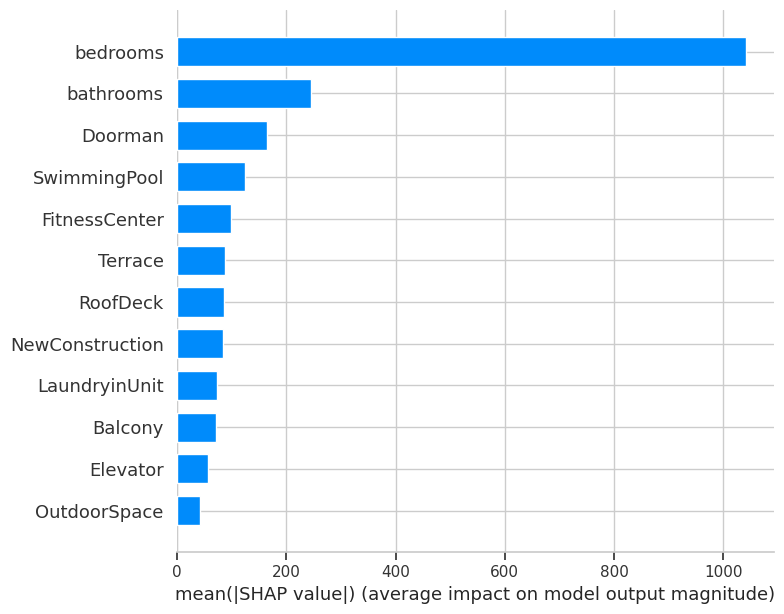

In [15]:
# (6.5) SHAP: use the linear explainer on the Lasso model, rank by mean|SHAP|.
t0 = time.time()
import shap
explainer = shap.LinearExplainer(base_lasso, Xtr)
shap_values = explainer.shap_values(Xva)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
top10_shap = shap_imp.head(10).index.tolist()
r = evaluate(top10_shap, "SHAP top-10"); r["sec"] = time.time() - t0
results.append(r); print("Top-10 SHAP:", top10_shap); print(r)

shap.summary_plot(shap_values, valid_df[FEATURE_COLS], feature_names=FEATURE_COLS,
                  plot_type="bar", show=False, max_display=12)
plt.tight_layout(); plt.show()

In [16]:
# (6.6) Compare methods on speed / metric / stability.
# Stability = how consistent the selected top-10 set is when each selector is
# rerun on 3 bootstrap resamples of the training data (mean pairwise Jaccard).
def selection_stability(select_fn, n_runs=3):
    sets = []
    for rs in range(n_runs):
        boot = train_df.sample(n=len(train_df), replace=True, random_state=rs)
        sc = StandardScaler().fit(boot[FEATURE_COLS].values)
        sets.append(set(select_fn(boot, sc)))
    js = []                                          # mean pairwise Jaccard
    for i in range(len(sets)):
        for j in range(i + 1, len(sets)):
            inter = len(sets[i] & sets[j]); union = len(sets[i] | sets[j])
            js.append(inter / union if union else 1.0)
    return float(np.mean(js))

def sel_lasso_fn(a, sc):
    m = Lasso(alpha=1.0, random_state=RANDOM_STATE).fit(sc.transform(a[FEATURE_COLS].values), a[TARGET].values)
    return pd.Series(np.abs(m.coef_), index=FEATURE_COLS).sort_values(ascending=False).head(10).index.tolist()

def sel_nan_fn(a, sc):
    return nan_corr_select(a, FEATURE_COLS, top=10)

def sel_perm_fn(a, sc):
    X = sc.transform(a[FEATURE_COLS].values); y = a[TARGET].values
    m = Lasso(alpha=1.0, random_state=RANDOM_STATE).fit(X, y)
    imp = permutation_importance_scratch(m, X, y, n_repeats=5)
    return pd.Series(imp, index=FEATURE_COLS).sort_values(ascending=False).head(10).index.tolist()

def sel_shap_fn(a, sc):
    X = sc.transform(a[FEATURE_COLS].values); y = a[TARGET].values
    m = Lasso(alpha=1.0, random_state=RANDOM_STATE).fit(X, y)
    sv = shap.LinearExplainer(m, X).shap_values(X)
    return pd.Series(np.abs(sv).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False).head(10).index.tolist()

res_df = pd.DataFrame(results).set_index("method").round(3)
res_df.loc["Lasso top-10 (by weight)", "stability"] = round(selection_stability(sel_lasso_fn), 3)
res_df.loc["nan+corr+variance top-10", "stability"] = round(selection_stability(sel_nan_fn), 3)
res_df.loc["Permutation top-10", "stability"] = round(selection_stability(sel_perm_fn), 3)
res_df.loc["SHAP top-10", "stability"] = round(selection_stability(sel_shap_fn), 3)
print(res_df.fillna("-"))

Background dataset has 6000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6000 when initializing the masker.


Background dataset has 6000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6000 when initializing the masker.


Background dataset has 6000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6000 when initializing the masker.


                          n_features  valid_RMSE  test_RMSE  test_R2    sec  \
method                                                                        
Lasso (all features)              24     355.436    362.965    0.931      -   
Lasso top-10 (by weight)          10     375.835    392.634    0.919  0.003   
nan+corr+variance top-10          10     513.637    527.138    0.855  0.024   
Permutation top-10                10     375.835    392.634    0.919  0.142   
SHAP top-10                       10     375.835    392.634    0.919  0.437   

                         stability  
method                              
Lasso (all features)             -  
Lasso top-10 (by weight)       1.0  
nan+corr+variance top-10     0.545  
Permutation top-10             1.0  
SHAP top-10                    1.0  


**Reading the comparison.**
- **Speed:** filter/unsupervised (`nan+corr`) and reading Lasso weights are
  essentially free; **permutation importance** costs `n_repeats × n_features`
  scorings; **SHAP** is in between for a linear model but grows fast for complex
  models.
- **Metric:** because the data is linear, all model-based rankings recover the
  same high-weight amenities (Doorman, SwimmingPool, FitnessCenter, Terrace,
  Balcony, ...), so top-10 keeps almost all of the test R² of the full model.
- **Stability:** the model-based rankings (Lasso weights, permutation
  importance, SHAP) are perfectly stable across bootstrap resamples
  (Jaccard = 1.0); the unsupervised variance ranking is the least stable
  because it ignores the target. Overall **Lasso/SHAP** give the best
  speed-quality-stability trade-off here.

## Chapter V.7 — Hyperparameter optimization (ElasticNet)

We tune `alpha` and `l1_ratio` for `ElasticNet` with (1) our own Grid Search,
(2) our own Random Search, then (3) Optuna, and compare. Finally we run Optuna
**inside a cross-validation** scheme for an honest objective.

In [17]:
from sklearn.linear_model import ElasticNet

def fit_score(alpha, l1_ratio, Xtr, ytr, Xva, yva):
    m = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=RANDOM_STATE, max_iter=5000)
    m.fit(Xtr, ytr)
    return mean_squared_error(yva, m.predict(Xva)) ** 0.5

# ---- (7.1) Grid Search -------------------------------------------------------
alpha_grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
l1_grid = [0.05, 0.2, 0.5, 0.8, 0.95]

t0 = time.time()
grid_results = []
for a in alpha_grid:
    for l1 in l1_grid:
        grid_results.append((a, l1, fit_score(a, l1, Xtr, ytr, Xva, yva)))
grid_time = time.time() - t0
best_grid = min(grid_results, key=lambda r: r[2])
print(f"GridSearch: {len(grid_results)} fits in {grid_time:.2f}s")
print(f"  best alpha={best_grid[0]}, l1_ratio={best_grid[1]}, valid_RMSE={best_grid[2]:.2f}")

GridSearch: 35 fits in 0.11s
  best alpha=0.1, l1_ratio=0.95, valid_RMSE=355.44


In [18]:
# ---- (7.1) Random Search -----------------------------------------------------
rng = np.random.default_rng(RANDOM_STATE)
n_iter = 25
t0 = time.time()
rand_results = []
for _ in range(n_iter):
    a = float(10 ** rng.uniform(-2, 1))         # log-uniform over [0.01, 10]
    l1 = float(rng.uniform(0.01, 0.99))
    rand_results.append((a, l1, fit_score(a, l1, Xtr, ytr, Xva, yva)))
rand_time = time.time() - t0
best_rand = min(rand_results, key=lambda r: r[2])
print(f"RandomSearch: {n_iter} fits in {rand_time:.2f}s")
print(f"  best alpha={best_rand[0]:.3f}, l1_ratio={best_rand[1]:.3f}, valid_RMSE={best_rand[2]:.2f}")

RandomSearch: 25 fits in 0.09s
  best alpha=0.019, l1_ratio=0.966, valid_RMSE=355.48


In [19]:
# ---- (7.2/7.3) Fit the best grid model and report TEST metrics ----------------
best_a, best_l1, _ = best_grid
final = ElasticNet(alpha=best_a, l1_ratio=best_l1, random_state=RANDOM_STATE, max_iter=5000)
final.fit(Xtr, ytr)
test_rmse = mean_squared_error(yte, final.predict(Xte)) ** 0.5
print(f"Best GridSearch ElasticNet -> test RMSE={test_rmse:.2f}, "
      f"test R2={r2_score(yte, final.predict(Xte)):.3f}")

Best GridSearch ElasticNet -> test RMSE=362.75, test R2=0.931


In [20]:
# ---- (7.4/7.5) Optuna with the SAME hold-out objective -----------------------
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    a = trial.suggest_float("alpha", 1e-2, 1e1, log=True)
    l1 = trial.suggest_float("l1_ratio", 0.01, 0.99)
    return fit_score(a, l1, Xtr, ytr, Xva, yva)

t0 = time.time()
study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=40, show_progress_bar=False)
optuna_time = time.time() - t0
print(f"Optuna: 40 trials in {optuna_time:.2f}s")
print(f"  best params={study.best_params}, valid_RMSE={study.best_value:.2f}")

compare = pd.DataFrame([
    {"method": "GridSearch",  "fits": len(grid_results), "sec": round(grid_time, 2),  "best_valid_RMSE": round(best_grid[2], 2)},
    {"method": "RandomSearch","fits": n_iter,            "sec": round(rand_time, 2),  "best_valid_RMSE": round(best_rand[2], 2)},
    {"method": "Optuna(TPE)", "fits": 40,                "sec": round(optuna_time, 2),"best_valid_RMSE": round(study.best_value, 2)},
]).set_index("method")
print("\n", compare)

Optuna: 40 trials in 0.18s
  best params={'alpha': 0.010839826352662662, 'l1_ratio': 0.6287112814263283}, valid_RMSE=355.45

               fits   sec  best_valid_RMSE
method                                   
GridSearch      35  0.11           355.44
RandomSearch    25  0.09           355.48
Optuna(TPE)     40  0.18           355.45


Optuna + GroupKFold CV:
  best params: {'alpha': 0.05028089046179029, 'l1_ratio': 0.987744990702026}
  best CV mean RMSE: 362.66


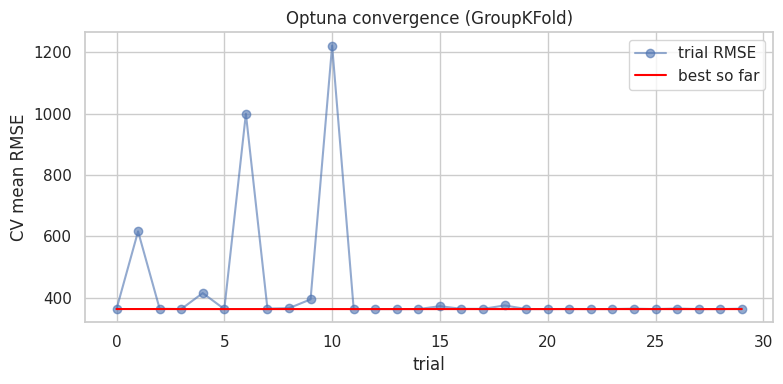

In [21]:
# ---- (7.6) Run Optuna on a CROSS-VALIDATION objective (our GroupKFold) --------
group_splits = group_kfold_split(model_df, k=5)

def cv_objective(trial):
    a = trial.suggest_float("alpha", 1e-2, 1e1, log=True)
    l1 = trial.suggest_float("l1_ratio", 0.01, 0.99)
    rmses = []
    for tr, te in group_splits:
        sc = StandardScaler().fit(X_all[tr])
        m = ElasticNet(alpha=a, l1_ratio=l1, random_state=RANDOM_STATE, max_iter=5000)
        m.fit(sc.transform(X_all[tr]), y_all[tr])
        rmses.append(mean_squared_error(y_all[te], m.predict(sc.transform(X_all[te]))) ** 0.5)
    return float(np.mean(rmses))

study_cv = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cv.optimize(cv_objective, n_trials=30, show_progress_bar=False)
print("Optuna + GroupKFold CV:")
print("  best params:", study_cv.best_params)
print(f"  best CV mean RMSE: {study_cv.best_value:.2f}")

# History plot
fig, ax = plt.subplots(figsize=(8, 4))
vals = [t.value for t in study_cv.trials]
ax.plot(vals, marker="o", alpha=0.6, label="trial RMSE")
ax.plot(np.minimum.accumulate(vals), color="red", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("CV mean RMSE"); ax.set_title("Optuna convergence (GroupKFold)")
ax.legend(); plt.tight_layout(); plt.show()

## Summary / conclusions

- **Validation:** correct splitting is the backbone of honest evaluation.
  For independent listings plain K-Fold is fine, but because a **manager**
  prices many flats, **GroupKFold** is the leakage-safe default; **TimeSeriesSplit**
  is mandatory whenever we deploy forward in time.
- **Determinism** (seeded splits) makes every result above reproducible.
- **Feature selection:** Lasso weights / SHAP recovered the truly predictive
  amenities and a top-10 model matched the full model on test R² while being
  cheaper. Permutation importance agrees but costs more; the unsupervised
  nan+corr filter is fastest but least stable.
- **Hyperparameter optimization:** Grid search is exhaustive but scales badly;
  random search matches it with fewer fits; **Optuna (TPE)** reaches the best
  validation RMSE in the fewest trials by *learning* from past evaluations, and
  combined with GroupKFold gives the most trustworthy tuned model.